# Jaccpot Single-N GPU Memory Probe

This notebook isolates one particle count and reports:
- whole-device GPU memory snapshots from `nvidia-smi`
- prepared-state object memory accounting
- compiled static memory estimates from `memory_analysis()`
- one `prepare_state` timing and one `evaluate_prepared_state` timing


## Large-N Runtime Toggle
These benchmarks now support the dedicated `large_n` runtime path. Set `GPU_DEVICE = "9"` and `RUNTIME_PATH = "large_n"` below for the new path, and uses the canonical large_n runtime path.

In [1]:
import os
GPU_DEVICE = "1"
RUNTIME_PATH = "large_n"
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_DEVICE
print(f"CUDA_VISIBLE_DEVICES={GPU_DEVICE}, RUNTIME_PATH={RUNTIME_PATH}")

def inject_runtime_path(kwargs):
    updated = dict(kwargs)
    updated["runtime_path"] = RUNTIME_PATH
    return updated


CUDA_VISIBLE_DEVICES=1, RUNTIME_PATH=large_n


In [2]:
import os

# --- Option A: automatic GPU selection with autocvd ---
USE_AUTOCVD = False
AUTOCVD_NUM_GPUS = 1
AUTOCVD_LEAST_USED = True
AUTOCVD_EXCLUDE = []

# --- Option B: manual selection (set to string like '0' or '0,1') ---
MANUAL_CUDA_VISIBLE_DEVICES = GPU_DEVICE  # None #"1,2,3,4,5,6,7,8,9"#None

if MANUAL_CUDA_VISIBLE_DEVICES is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = MANUAL_CUDA_VISIBLE_DEVICES
    print("Set CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
elif USE_AUTOCVD:
    try:
        from autocvd import autocvd

        autocvd(
            num_gpus=AUTOCVD_NUM_GPUS,
            least_used=AUTOCVD_LEAST_USED,
            exclude=AUTOCVD_EXCLUDE,
        )
        print(
            "autocvd selected CUDA_VISIBLE_DEVICES =",
            os.environ.get("CUDA_VISIBLE_DEVICES"),
        )
    except ImportError:
        print(
            "autocvd is not installed. Install it or set MANUAL_CUDA_VISIBLE_DEVICES."
        )
else:
    print(
        "Using existing CUDA visibility:",
        os.environ.get("CUDA_VISIBLE_DEVICES", "<all visible>"),
    )

INDEX_PRECISION = "int32"

os.environ["JAX_ENABLE_X64"] = "1"

os.environ["JACCPOT_INDEX_PRECISION"] = INDEX_PRECISION
os.environ["YGGDRAX_INDEX_PRECISION"] = INDEX_PRECISION
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")
os.environ.setdefault("JACCPOT_PREPARE_DIAGNOSTICS", "1")
os.environ.setdefault("YGGDRAX_TRAVERSAL_DIAGNOSTICS", "1")

if "--xla_gpu_enable_command_buffer=" not in os.environ.get("XLA_FLAGS", ""):
    existing_xla_flags = os.environ.get("XLA_FLAGS", "").strip()
    command_buffer_off = "--xla_gpu_enable_command_buffer="
    os.environ["XLA_FLAGS"] = (
        f"{existing_xla_flags} {command_buffer_off}".strip()
        if existing_xla_flags
        else command_buffer_off
    )

VISIBLE_PHYSICAL_GPUS = [
    part.strip()
    for part in os.environ.get("CUDA_VISIBLE_DEVICES", "").split(",")
    if part.strip() != ""
]
NVIDIA_SMI_GPU_INDEX = int(VISIBLE_PHYSICAL_GPUS[0]) if VISIBLE_PHYSICAL_GPUS else 0

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES", "<all visible>"))
print("JACCPOT_INDEX_PRECISION:", os.environ.get("JACCPOT_INDEX_PRECISION"))
print("JACCPOT_PREPARE_DIAGNOSTICS:", os.environ.get("JACCPOT_PREPARE_DIAGNOSTICS"))
print("YGGDRAX_TRAVERSAL_DIAGNOSTICS:", os.environ.get("YGGDRAX_TRAVERSAL_DIAGNOSTICS"))
print("nvidia-smi physical GPU index:", NVIDIA_SMI_GPU_INDEX)


Set CUDA_VISIBLE_DEVICES = 1
CUDA_VISIBLE_DEVICES: 1
JACCPOT_INDEX_PRECISION: int32
JACCPOT_PREPARE_DIAGNOSTICS: 1
YGGDRAX_TRAVERSAL_DIAGNOSTICS: 1
nvidia-smi physical GPU index: 1


In [3]:
import gc
import inspect
import pathlib
import subprocess
import sys
import threading
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = pathlib.Path.cwd().resolve()
if not (REPO_ROOT / "jaccpot").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) in sys.path:
    sys.path.remove(str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT))

from jaccpot import (
    FMMAdvancedConfig,
    FMMPreset,
    FarFieldConfig,
    FastMultipoleMethod,
    NearFieldConfig,
    RuntimePolicyConfig,
    TreeConfig,
)
from yggdrax.interactions import DualTreeTraversalConfig
from examples import benchmark_utils as bench_utils

all_devices = jax.devices()
gpu_devices = [d for d in all_devices if d.platform == "gpu"]
print("JAX backend:", jax.default_backend())
print("Visible devices:", all_devices)
if not gpu_devices:
    raise RuntimeError("No GPU visible to JAX.")
gpu_device = gpu_devices[0]
print("Using GPU:", gpu_device)


JAX backend: gpu
Visible devices: [CudaDevice(id=0)]
Using GPU: cuda:0


In [4]:
import inspect
import jaccpot
import jaccpot.runtime._fmm_impl as jf
import yggdrax
import yggdrax._interactions_impl as yi

print("jaccpot:", jaccpot.__file__)
print("yggdrax:", yggdrax.__file__)

src_j = inspect.getsource(jf.FastMultipoleMethod._resolve_runtime_execution_overrides)
print("streamed/grouped guard:", "if self.streamed_far_pairs and grouped_interactions" in src_j)
print("minimum-memory traversal None:", "traversal_config = None" in src_j)

src_y = inspect.getsource(yi)
print("count-pass fill cap:", "_COUNT_PASS_FILL_INTERACTION_CAP = 4096" in src_y)


jaccpot: /export/home/tbuck/jaccpot/jaccpot/__init__.py
yggdrax: /export/home/tbuck/yggdrax/yggdrax/__init__.py
streamed/grouped guard: True
minimum-memory traversal None: False
count-pass fill cap: True


In [5]:
# Single-N configuration.
num_particles = 2097152 #1048576 #4194304 #18874368 #33554432 #16777216  #16777216 #524288 #131072 #262_144
leaf_size = 256 #128 #64
max_order = 4
softening = 1e-3
working_dtype = jnp.float32
seed = 0
baseline_profile = "engblom_prepare_optimized_single_n"
prepare_warmup = 1
prepare_runs = 1
evaluate_warmup = 1
evaluate_runs = 1
evaluate_jit_traversal = True
disable_jit_for_large_n = False
peak_poll_interval_s = 0.02
write_jax_memory_profiles = True
compile_analysis_enabled = False
component_peak_enabled = False
memory_sweep_enabled = False
prepare_analysis_enabled = True
prepare_peak_compare_enabled = False
prepare_stage_memory_split_enabled = True
os.environ["JACCPOT_PREPARE_STAGE_MEMORY_SPLIT_ENABLED"] = "1" if bool(prepare_stage_memory_split_enabled) else "0"
prepare_stage_memory_split_sweep_enabled = True
prepare_stage_memory_split_particle_counts = [262144, 524288, 1048576]
prepare_stage_memory_split_leaf_sizes = [128, 256]
prepare_stage_memory_split_warmup = 0
prepare_stage_memory_split_runs = 1
memory_sweep_m2l_chunks = [1024, 512, 256]
memory_sweep_nearfield_chunks = [64, 128]
mac_compare_enabled = False
leaf_size_production_compare_enabled = True
leaf_size_production_compare_leaf_sizes = [128, 256]
leaf_size_production_compare_warmup = 1
leaf_size_production_compare_runs = 1
mac_compare_types = ["engblom", "dehnen", "dehnen_error"]
mac_compare_warmup = 1
fail_fast = True

# Lane profile toggle for single-N memory benchmarking.
single_n_lane_label = "fast_lane"  # options: "baseline", "fast_lane"
single_n_fast_lane_block_size = 8
single_n_lane_profiles = {
    "baseline": {
        "target_block_size": 0,
        "env": {
            "YGGDRAX_NEARFIELD_TARGET_BLOCK_SIZE": "0",
            "JACCPOT_LARGE_N_TARGET_BLOCK_SIZE": "0",
        },
    },
    "fast_lane": {
        "target_block_size": int(single_n_fast_lane_block_size),
        "env": {
            "YGGDRAX_NEARFIELD_TARGET_BLOCK_SIZE": str(int(single_n_fast_lane_block_size)),
            "JACCPOT_LARGE_N_TARGET_BLOCK_SIZE": str(int(single_n_fast_lane_block_size)),
        },
    },
}
if str(single_n_lane_label) not in single_n_lane_profiles:
    raise ValueError(f"unknown single_n_lane_label={single_n_lane_label!r}; expected one of {sorted(single_n_lane_profiles)}")
single_n_lane_profile = dict(single_n_lane_profiles[str(single_n_lane_label)])
single_n_target_block_size = int(single_n_lane_profile["target_block_size"])
for _env_key, _env_value in single_n_lane_profile.get("env", {}).items():
    os.environ[str(_env_key)] = str(_env_value)
single_n_run_suffix = f"{single_n_lane_label}_b{single_n_target_block_size}"
print("single-N lane:", single_n_lane_label, "target_block_size=", single_n_target_block_size)
print("single-N run suffix:", single_n_run_suffix)

def _round_up_pow2(value, *, min_value, max_value):
    value = max(int(min_value), int(value))
    value = 1 << (value - 1).bit_length()
    return int(min(int(max_value), value))


def _candidate_traversal_cfg(*, queue, block, interactions, neighbors):
    return {
        "max_pair_queue": int(queue),
        "process_block": int(block),
        "max_interactions_per_node": int(interactions),
        "max_neighbors_per_leaf": int(neighbors),
    }


def traversal_seed_for_num_particles(num_particles):
    n = int(num_particles)
    if n <= 4194304 and n > 2097152:
        return _candidate_traversal_cfg(
            queue=4194304,
            block=512,
            interactions=65536,
            neighbors=65536,
        )
    scale = max(1.0, float(n) / 524288.0)
    queue = _round_up_pow2(scale * 524288, min_value=65536, max_value=33554432)
    interactions = _round_up_pow2(scale * 16384, min_value=4096, max_value=131072)
    neighbors = _round_up_pow2(scale * 8192, min_value=1024, max_value=131072)
    if n >= 2097152:
        neighbors = max(neighbors, 32768)
        interactions = max(interactions, 32768)
    if n >= 8388608:
        neighbors = max(neighbors, 65536)
        interactions = max(interactions, 65536)
    if n <= 131072:
        process_block = 64
    elif n <= 524288:
        process_block = 128 if queue <= 131072 else 256
    elif n <= 4194304:
        process_block = 512 if queue >= 2097152 else 256
    else:
        process_block = 1024 if queue >= 4194304 else 512
    return _candidate_traversal_cfg(
        queue=queue,
        block=process_block,
        interactions=interactions,
        neighbors=neighbors,
    )


def traversal_sweep_candidates_for_num_particles(num_particles):
    baseline = traversal_seed_for_num_particles(num_particles)
    base_queue = int(baseline["max_pair_queue"])
    base_block = int(baseline["process_block"])
    base_interactions = int(baseline["max_interactions_per_node"])
    base_neighbors = int(baseline["max_neighbors_per_leaf"])
    if int(num_particles) <= 4194304 and int(num_particles) > 2097152:
        return [
            _candidate_traversal_cfg(queue=2097152, block=512, interactions=32768, neighbors=32768),
            _candidate_traversal_cfg(queue=4194304, block=512, interactions=65536, neighbors=65536),
            _candidate_traversal_cfg(queue=4194304, block=1024, interactions=65536, neighbors=65536),
            _candidate_traversal_cfg(queue=8388608, block=1024, interactions=65536, neighbors=65536),
        ]
    queue_up = _round_up_pow2(base_queue * 2, min_value=65536, max_value=33554432)
    interactions_up = _round_up_pow2(base_interactions * 2, min_value=4096, max_value=131072)
    neighbors_up = _round_up_pow2(base_neighbors * 2, min_value=1024, max_value=131072)
    queue_down = _round_up_pow2(max(65536, base_queue // 2), min_value=65536, max_value=33554432)
    block_down = 256 if base_block >= 256 else base_block
    block_up = 1024 if queue_up >= 4194304 else 512 if queue_up >= 2097152 else 256
    raw_candidates = [
        _candidate_traversal_cfg(
            queue=queue_down,
            block=block_down,
            interactions=max(4096, base_interactions // 2),
            neighbors=max(1024, base_neighbors // 2),
        ),
        _candidate_traversal_cfg(
            queue=base_queue,
            block=base_block,
            interactions=base_interactions,
            neighbors=base_neighbors,
        ),
        _candidate_traversal_cfg(
            queue=base_queue,
            block=max(base_block, 512 if base_queue >= 2097152 else 256),
            interactions=base_interactions,
            neighbors=neighbors_up,
        ),
        _candidate_traversal_cfg(
            queue=queue_up,
            block=block_up,
            interactions=base_interactions,
            neighbors=base_neighbors,
        ),
        _candidate_traversal_cfg(
            queue=queue_up,
            block=block_up,
            interactions=interactions_up,
            neighbors=neighbors_up,
        ),
    ]
    dedup = []
    seen = set()
    for cfg in raw_candidates:
        key = (
            int(cfg["max_pair_queue"]),
            int(cfg["process_block"]),
            int(cfg["max_interactions_per_node"]),
            int(cfg["max_neighbors_per_leaf"]),
        )
        if key in seen:
            continue
        seen.add(key)
        dedup.append(cfg)
    return dedup


baseline_traversal_cfg = traversal_seed_for_num_particles(num_particles)
memory_sweep_traversal_candidates = traversal_sweep_candidates_for_num_particles(num_particles)
prepare_peak_compare_candidates = [
    {
        "label": (
            f"engblom_baseline_{int(baseline_traversal_cfg['max_pair_queue'])}_"
            f"{int(baseline_traversal_cfg['max_interactions_per_node'])}_"
            f"{int(baseline_traversal_cfg['max_neighbors_per_leaf'])}_m2l1024_nf128"
        ),
        "traversal_cfg": dict(baseline_traversal_cfg),
        "m2l_chunk_size": 1024,
        "nearfield_edge_chunk_size": 128,
    },
]
if int(num_particles) > 1048576:
    prepare_peak_compare_candidates.extend(
        [
            {
                "label": "engblom_reference_1m_scaled_nf128",
                "traversal_cfg": traversal_seed_for_num_particles(1048576),
                "m2l_chunk_size": 1024,
                "nearfield_edge_chunk_size": 128,
            },
            {
                "label": "engblom_control_2m_scaled_nf64",
                "traversal_cfg": traversal_seed_for_num_particles(2097152),
                "m2l_chunk_size": 1024,
                "nearfield_edge_chunk_size": 64,
            },
        ]
    )
elif int(num_particles) > 524288:
    prepare_peak_compare_candidates.extend(
        [
            {
                "label": "engblom_reference_262k_scaled_nf128",
                "traversal_cfg": traversal_seed_for_num_particles(262144),
                "m2l_chunk_size": 1024,
                "nearfield_edge_chunk_size": 128,
            },
            {
                "label": "engblom_control_1m_scaled_nf64",
                "traversal_cfg": traversal_seed_for_num_particles(1048576),
                "m2l_chunk_size": 1024,
                "nearfield_edge_chunk_size": 64,
            },
        ]
    )
else:
    prepare_peak_compare_candidates.append(
        {
            "label": "engblom_control_524k_scaled_nf64",
            "traversal_cfg": traversal_seed_for_num_particles(524288),
            "m2l_chunk_size": 1024,
            "nearfield_edge_chunk_size": 64,
        }
    )

memory_first_advanced = FMMAdvancedConfig(
    tree=TreeConfig(
        tree_type="radix",
        mode="lbvh",
        leaf_target=64,
        refine_local=False,
        max_refine_levels=0,
        aspect_threshold=16.0,
    ),
    farfield=FarFieldConfig(
        grouped_interactions=False,
        mode="pair_grouped",
        rotation="solidfmm",
        m2l_chunk_size=1024,
        l2l_chunk_size=None,
        streamed_far_pairs=True,
        mixed_order=False,
        mixed_order_min_order=None,
    ),
    nearfield=NearFieldConfig(
        mode="bucketed",
        edge_chunk_size=128,
        precompute_scatter_schedules=False,
    ),
    runtime=RuntimePolicyConfig(
        host_refine_mode="off",
        fail_fast=fail_fast,
        jit_tree=True,
        jit_traversal=True,
        memory_objective="minimum_memory",
        traversal_config=DualTreeTraversalConfig(
            max_pair_queue=int(baseline_traversal_cfg["max_pair_queue"]),
            process_block=int(baseline_traversal_cfg["process_block"]),
            max_interactions_per_node=int(baseline_traversal_cfg["max_interactions_per_node"]),
            max_neighbors_per_leaf=int(baseline_traversal_cfg["max_neighbors_per_leaf"]),
        ),
        pair_process_block=None,
        enable_interaction_cache=False,
        retain_traversal_result=False,
        retain_interactions=False,
        autotune_m2l_chunk=False,
        upward_leaf_batch_size=2048,
    ),
    mac_type="engblom",
    dehnen_radius_scale=1.0,
)

fmm_kwargs = dict(
    preset=FMMPreset.LARGE_N_GPU,
    basis="solidfmm",
    precision="fp32",
    theta=0.6,
    softening=softening,
    working_dtype=working_dtype,
    adaptive_order=False,
    advanced=memory_first_advanced,
)

jax_memory_profile_dir = REPO_ROOT / "benchmarks" / "jax_memory_profiles"
single_n_output_dir = REPO_ROOT / "benchmarks" / "single_n_memory"

config_df = pd.DataFrame(
    [
        {
            "num_particles": num_particles,
            "baseline_profile": str(baseline_profile),
            "leaf_size": leaf_size,
            "max_order": max_order,
            "working_dtype": str(jnp.dtype(working_dtype)),
            "preset": "large_n_gpu",
            "m2l_chunk_size": memory_first_advanced.farfield.m2l_chunk_size,
            "nearfield_edge_chunk_size": memory_first_advanced.nearfield.edge_chunk_size,
            "memory_objective": str(memory_first_advanced.runtime.memory_objective),
            "baseline_max_pair_queue": int(baseline_traversal_cfg["max_pair_queue"]),
            "baseline_process_block": int(baseline_traversal_cfg["process_block"]),
            "baseline_max_interactions_per_node": int(baseline_traversal_cfg["max_interactions_per_node"]),
            "baseline_max_neighbors_per_leaf": int(baseline_traversal_cfg["max_neighbors_per_leaf"]),
            "fail_fast": bool(memory_first_advanced.runtime.fail_fast),
            "evaluate_jit_traversal": bool(evaluate_jit_traversal),
            "disable_jit_for_large_n": bool(disable_jit_for_large_n),
            "peak_poll_interval_s": peak_poll_interval_s,
            "write_jax_memory_profiles": bool(write_jax_memory_profiles),
            "compile_analysis_enabled": bool(compile_analysis_enabled),
            "component_peak_enabled": bool(component_peak_enabled),
            "nvidia_smi_physical_gpu_index": NVIDIA_SMI_GPU_INDEX,
            "memory_sweep_enabled": bool(memory_sweep_enabled),
            "prepare_analysis_enabled": bool(prepare_analysis_enabled),
            "prepare_peak_compare_enabled": bool(prepare_peak_compare_enabled),
            "prepare_stage_memory_split_enabled": bool(prepare_stage_memory_split_enabled),
            "mac_compare_enabled": bool(mac_compare_enabled),
            "mac_compare_types": ",".join(str(v) for v in mac_compare_types),
            "mac_compare_warmup": int(mac_compare_warmup),
            "lane_label": str(single_n_lane_label),
            "target_block_size": int(single_n_target_block_size),
            "yggdrax_target_block_size_env": str(os.environ.get("YGGDRAX_NEARFIELD_TARGET_BLOCK_SIZE", "")),
            "jaccpot_target_block_size_env": str(os.environ.get("JACCPOT_LARGE_N_TARGET_BLOCK_SIZE", "")),
        }
    ]
)
config_df


single-N lane: fast_lane target_block_size= 8
single-N run suffix: fast_lane_b8


,num_particles,baseline_profile,leaf_size,max_order,working_dtype,preset,m2l_chunk_size,nearfield_edge_chunk_size,memory_objective,baseline_max_pair_queue,...,prepare_analysis_enabled,prepare_peak_compare_enabled,prepare_stage_memory_split_enabled,mac_compare_enabled,mac_compare_types,mac_compare_warmup,lane_label,target_block_size,yggdrax_target_block_size_env,jaccpot_target_block_size_env
0,2097152,engblom_prepare_optimized_single_n,256,4,float32,large_n_gpu,1024,128,minimum_memory,2097152,...,True,False,True,False,"engblom,dehnen,dehnen_error",1,fast_lane,8,8,8


In [6]:
fmm = FastMultipoleMethod(**fmm_kwargs)
print("resolved memory path:", bench_utils.resolved_large_n_memory_path_report(fmm))
print("fail_fast:", fmm._impl.fail_fast)
print(fmm._impl._resolve_runtime_execution_overrides(num_particles=int(num_particles)))


resolved memory path: {'resolved_runtime_path': 'large_n', 'resolved_memory_objective': 'minimum_memory', 'resolved_streamed_far_pairs': True, 'resolved_grouped_interactions': False, 'resolved_retain_traversal_result': False, 'resolved_retain_interactions': False, 'resolved_large_n_memory_path_active': True}
fail_fast: True
_RuntimeExecutionOverrides(traversal_config=DualTreeTraversalConfig(max_pair_queue=262144, process_block=256, max_interactions_per_node=8192, max_neighbors_per_leaf=4096), m2l_chunk_size=1024, l2l_chunk_size=None, grouped_interactions=False, farfield_mode='pair_grouped', center_mode='com', refine_local_override=False, adaptive_applied=False)


In [7]:
compile_analysis_enabled = bool(compile_analysis_enabled)
component_peak_enabled = bool(component_peak_enabled)
memory_sweep_enabled = bool(memory_sweep_enabled)
prepare_analysis_enabled = bool(prepare_analysis_enabled)
prepare_peak_compare_enabled = bool(prepare_peak_compare_enabled)
mac_compare_enabled = bool(mac_compare_enabled)

leaf_size_production_compare_enabled = bool(leaf_size_production_compare_enabled)


In [8]:
def _block_ready(value):
    return jax.tree_util.tree_map(
        lambda x: x.block_until_ready() if hasattr(x, "block_until_ready") else x,
        value,
    )


def _evaluate_prepared_kwargs(fmm):
    params = inspect.signature(fmm.evaluate_prepared_state).parameters
    if "jit_traversal" in params:
        return {"jit_traversal": bool(evaluate_jit_traversal)}
    return {}


def _clear_runtime_memory(fmm=None):
    if fmm is not None:
        clear_fn = getattr(fmm, "clear_runtime_caches", None)
        if callable(clear_fn):
            clear_fn(clear_jax_compilation=True)
        elif hasattr(fmm, "clear_prepared_state_cache"):
            fmm.clear_prepared_state_cache()
    jax.clear_caches()
    gc.collect()


def _array_nbytes(arr):
    try:
        shape = tuple(int(d) for d in getattr(arr, "shape", ()))
        dtype = np.dtype(getattr(arr, "dtype"))
    except Exception:
        return 0
    count = int(np.prod(np.asarray(shape, dtype=np.int64))) if shape else 1
    return int(count * int(dtype.itemsize))


def _iter_array_paths(obj, prefix="root"):
    if hasattr(obj, "shape") and hasattr(obj, "dtype"):
        yield prefix, obj
        return
    if obj is None:
        return
    if isinstance(obj, dict):
        for k, v in obj.items():
            yield from _iter_array_paths(v, f"{prefix}.{k}")
        return
    if isinstance(obj, (list, tuple)):
        if hasattr(obj, "_fields"):
            for name in obj._fields:
                try:
                    v = getattr(obj, name)
                except Exception:
                    continue
                yield from _iter_array_paths(v, f"{prefix}.{name}")
            return
        for i, v in enumerate(obj):
            yield from _iter_array_paths(v, f"{prefix}[{i}]")
        return
    if hasattr(obj, "__dict__"):
        for k, v in vars(obj).items():
            yield from _iter_array_paths(v, f"{prefix}.{k}")


def _subsystem_from_path(path):
    p = str(path)
    if ".upward" in p or ".multipoles" in p or ".mass_moments" in p:
        return "upward"
    if ".downward" in p or ".locals" in p:
        return "downward"
    if ".neighbor" in p or ".nearfield" in p:
        return "nearfield"
    if ".tree" in p or ".topology" in p or ".geometry" in p:
        return "tree_geometry"
    if ".interactions" in p:
        return "interactions"
    return "other"


def prepared_state_memory_tables(state):
    rows = []
    totals = {}
    total_bytes = 0
    for path, arr in _iter_array_paths(state, prefix="prepared"):
        nb = _array_nbytes(arr)
        if nb <= 0:
            continue
        total_bytes += nb
        subsystem = _subsystem_from_path(path)
        totals[subsystem] = totals.get(subsystem, 0) + nb
        rows.append(
            {
                "component": path,
                "subsystem": subsystem,
                "mb": nb / (1024 ** 2),
            }
        )
    path_df = pd.DataFrame(rows).sort_values("mb", ascending=False)
    subsystem_df = pd.DataFrame(
        [
            {"subsystem": k, "mb": v / (1024 ** 2)}
            for k, v in sorted(totals.items(), key=lambda kv: kv[1], reverse=True)
        ]
    )
    total_df = pd.DataFrame([{"component": "TOTAL_PREPARED_STATE", "mb": total_bytes / (1024 ** 2)}])
    return total_df, subsystem_df, path_df


def _query_gpu_memory_mb():
    cmd = [
        "nvidia-smi",
        "--id=%d" % int(NVIDIA_SMI_GPU_INDEX),
        "--query-gpu=memory.used,memory.total",
        "--format=csv,noheader,nounits",
    ]
    out = subprocess.run(cmd, check=True, capture_output=True, text=True)
    first = out.stdout.strip().splitlines()[0]
    used_mb, total_mb = [float(x.strip()) for x in first.split(",")[:2]]
    return used_mb, total_mb


def _query_gpu_memory_mb_by_pid(pid):
    cmd = [
        "nvidia-smi",
        "--id=%d" % int(NVIDIA_SMI_GPU_INDEX),
        "--query-compute-apps=pid,used_memory",
        "--format=csv,noheader,nounits",
    ]
    out = subprocess.run(cmd, check=True, capture_output=True, text=True)
    total_used_mb = 0.0
    for line in out.stdout.strip().splitlines():
        parts = [part.strip() for part in line.split(",")]
        if len(parts) < 2:
            continue
        try:
            row_pid = int(parts[0])
            row_used = float(parts[1])
        except Exception:
            continue
        if row_pid == int(pid):
            total_used_mb += float(row_used)
    return float(total_used_mb)


def gpu_memory_snapshot(label):
    row = {"label": label, "gpu_used_mb": np.nan, "gpu_total_mb": np.nan, "gpu_free_mb": np.nan}
    try:
        used_mb, total_mb = _query_gpu_memory_mb()
        row["gpu_used_mb"] = used_mb
        row["gpu_total_mb"] = total_mb
        row["gpu_free_mb"] = total_mb - used_mb
    except Exception as exc:
        row["error"] = f"{type(exc).__name__}: {exc}"
    return row


def allocator_memory_snapshot(label):
    row = {
        "label": label,
        "allocator_bytes_in_use_mb": np.nan,
        "allocator_peak_bytes_in_use_mb": np.nan,
        "allocator_bytes_reserved_mb": np.nan,
        "allocator_peak_bytes_reserved_mb": np.nan,
    }
    try:
        stats_fn = getattr(gpu_device, "memory_stats", None)
        if not callable(stats_fn):
            row["error"] = "memory_stats unavailable"
            return row
        stats = stats_fn() or {}
        row["allocator_bytes_in_use_mb"] = float(stats.get("bytes_in_use", np.nan)) / (1024 ** 2)
        row["allocator_peak_bytes_in_use_mb"] = float(stats.get("peak_bytes_in_use", np.nan)) / (1024 ** 2)
        row["allocator_bytes_reserved_mb"] = float(stats.get("bytes_reserved", np.nan)) / (1024 ** 2)
        row["allocator_peak_bytes_reserved_mb"] = float(stats.get("peak_bytes_reserved", np.nan)) / (1024 ** 2)
    except Exception as exc:
        row["error"] = f"{type(exc).__name__}: {exc}"
    return row


def peak_gpu_memory_trace(fn, *args, label, poll_interval_s=0.02, **kwargs):
    samples = []
    errors = []
    stop_event = threading.Event()

    def _poll():
        while not stop_event.is_set():
            ts = time.perf_counter()
            try:
                used_mb, total_mb = _query_gpu_memory_mb()
                samples.append({"label": label, "t_s": ts, "gpu_used_mb": used_mb, "gpu_total_mb": total_mb})
            except Exception as exc:
                errors.append(f"{type(exc).__name__}: {exc}")
                break
            stop_event.wait(poll_interval_s)

    before = gpu_memory_snapshot(f"{label}_before")
    alloc_before = allocator_memory_snapshot(f"{label}_before")
    worker = threading.Thread(target=_poll, daemon=True)
    worker.start()
    started = time.perf_counter()
    try:
        result = fn(*args, **kwargs)
        result = _block_ready(result)
    finally:
        stop_event.set()
        worker.join(timeout=max(1.0, 10.0 * poll_interval_s))
    finished = time.perf_counter()
    after = gpu_memory_snapshot(f"{label}_after")
    alloc_after = allocator_memory_snapshot(f"{label}_after")
    trace_df = pd.DataFrame(samples)
    peak_used_mb = float(trace_df["gpu_used_mb"].max()) if not trace_df.empty else float(after.get("gpu_used_mb", np.nan))
    peak_delta_mb = peak_used_mb - float(before.get("gpu_used_mb", np.nan))
    summary = {
        "phase": label,
        "wall_seconds": finished - started,
        "gpu_used_before_mb": before.get("gpu_used_mb", np.nan),
        "gpu_used_after_mb": after.get("gpu_used_mb", np.nan),
        "gpu_peak_used_mb": peak_used_mb,
        "gpu_peak_delta_mb": peak_delta_mb,
        "allocator_in_use_before_mb": alloc_before.get("allocator_bytes_in_use_mb", np.nan),
        "allocator_in_use_after_mb": alloc_after.get("allocator_bytes_in_use_mb", np.nan),
        "allocator_peak_before_mb": alloc_before.get("allocator_peak_bytes_in_use_mb", np.nan),
        "allocator_peak_after_mb": alloc_after.get("allocator_peak_bytes_in_use_mb", np.nan),
        "allocator_peak_delta_mb": (
            float(alloc_after.get("allocator_peak_bytes_in_use_mb", np.nan))
            - float(alloc_before.get("allocator_peak_bytes_in_use_mb", np.nan))
        ),
        "num_samples": int(len(samples)),
        "poll_interval_s": float(poll_interval_s),
        "error": "" if not errors else errors[0],
    }
    allocator_df = pd.DataFrame([alloc_before, alloc_after])
    return result, pd.DataFrame([summary]), trace_df, before, after, allocator_df


def maybe_save_jax_memory_profile(path):
    try:
        save_fn = getattr(jax.profiler, "save_device_memory_profile", None)
        if save_fn is None:
            return {"path": str(path), "written": False, "error": "save_device_memory_profile unavailable"}
        path.parent.mkdir(parents=True, exist_ok=True)
        save_fn(str(path))
        return {"path": str(path), "written": True, "error": ""}
    except Exception as exc:
        return {"path": str(path), "written": False, "error": f"{type(exc).__name__}: {exc}"}


def memory_analysis_rows(fmm, positions, masses):
    rows = []
    rows.append(
        {
            "phase": "prepare",
            "temp_mb": np.nan,
            "arg_mb": np.nan,
            "out_mb": np.nan,
            "alias_mb": np.nan,
            "total_mb": np.nan,
            "error": "prepare_state memory_analysis skipped: outer jax.jit compile of prepare_state is disabled for large-N runtime measurements",
        }
    )

    try:
        state = fmm.prepare_state(positions, masses, leaf_size=int(leaf_size), max_order=int(max_order))
        state = _block_ready(state)
        eval_kwargs = _evaluate_prepared_kwargs(fmm)
        eval_jit = jax.jit(lambda st: fmm.evaluate_prepared_state(st, **eval_kwargs))
        eval_compiled = eval_jit.lower(state).compile()
        stats = eval_compiled.memory_analysis()
        if stats is not None:
            rows.append(
                {
                    "phase": "evaluate",
                    "temp_mb": float(stats.temp_size_in_bytes) / (1024 ** 2),
                    "arg_mb": float(stats.argument_size_in_bytes) / (1024 ** 2),
                    "out_mb": float(stats.output_size_in_bytes) / (1024 ** 2),
                    "alias_mb": float(stats.alias_size_in_bytes) / (1024 ** 2),
                    "total_mb": (
                        float(stats.temp_size_in_bytes)
                        + float(stats.argument_size_in_bytes)
                        + float(stats.output_size_in_bytes)
                        - float(stats.alias_size_in_bytes)
                    ) / (1024 ** 2),
                    "error": "",
                }
            )
        del eval_compiled
    except Exception as exc:
        rows.append({"phase": "evaluate", "temp_mb": np.nan, "arg_mb": np.nan, "out_mb": np.nan, "alias_mb": np.nan, "total_mb": np.nan, "error": f"{type(exc).__name__}: {exc}"})
    return pd.DataFrame(rows)


def serialize_fmm_kwargs_for_worker(fmm_kwargs):
    probe_fmm = FastMultipoleMethod(**fmm_kwargs)
    advanced = probe_fmm.advanced
    traversal_cfg = advanced.runtime.traversal_config
    traversal_payload = None
    if traversal_cfg is not None:
        traversal_payload = {
            "process_block": int(traversal_cfg.process_block),
            "max_neighbors_per_leaf": int(traversal_cfg.max_neighbors_per_leaf),
            "max_interactions_per_node": int(traversal_cfg.max_interactions_per_node),
            "max_pair_queue": int(traversal_cfg.max_pair_queue),
        }
    preset_value = fmm_kwargs.get("preset", "fast")
    if hasattr(preset_value, "value"):
        preset_value = preset_value.value
    payload = {
        "preset": str(preset_value),
        "basis": str(fmm_kwargs.get("basis", "solidfmm")),
        "theta": float(fmm_kwargs.get("theta", 0.6)),
        "softening": float(fmm_kwargs.get("softening", 1e-3)),
        "working_dtype": str(jnp.dtype(getattr(probe_fmm._impl, "working_dtype", jnp.float32))),
        "tree_type": str(advanced.tree.tree_type),
        "leaf_target": int(advanced.tree.leaf_target),
        "farfield_rotation": str(advanced.farfield.rotation),
        "farfield_mode": str(advanced.farfield.mode),
        "grouped_interactions": bool(advanced.farfield.grouped_interactions),
        "streamed_far_pairs": advanced.farfield.streamed_far_pairs,
        "mixed_order": bool(advanced.farfield.mixed_order),
        "mixed_order_min_order": advanced.farfield.mixed_order_min_order,
        "nearfield_mode": str(advanced.nearfield.mode),
        "nearfield_edge_chunk_size": int(advanced.nearfield.edge_chunk_size),
        "precompute_scatter_schedules": bool(advanced.nearfield.precompute_scatter_schedules),
        "pair_process_block": (
            None if advanced.runtime.pair_process_block is None else int(advanced.runtime.pair_process_block)
        ),
        "memory_objective": str(advanced.runtime.memory_objective),
        "fail_fast": bool(advanced.runtime.fail_fast),
        "jit_traversal": bool(advanced.runtime.jit_traversal),
        "traversal_config": traversal_payload,
        "enable_interaction_cache": bool(advanced.runtime.enable_interaction_cache),
        "retain_traversal_result": bool(advanced.runtime.retain_traversal_result),
        "retain_interactions": bool(advanced.runtime.retain_interactions),
        "autotune_m2l_chunk": bool(advanced.runtime.autotune_m2l_chunk),
        "adaptive_order": bool(getattr(probe_fmm._impl, "adaptive_order", False)),
        "p_gears": [int(v) for v in getattr(probe_fmm._impl, "p_gears", tuple())],
        "adaptive_error_model": str(getattr(probe_fmm._impl, "adaptive_error_model", "tail_proxy")),
        "adaptive_eps": (
            None if getattr(probe_fmm._impl, "adaptive_eps", None) is None else float(getattr(probe_fmm._impl, "adaptive_eps"))
        ),
        "mac_force_scale_mode": str(getattr(probe_fmm._impl, "mac_force_scale_mode", "prev")),
        "mac_type": str(advanced.mac_type),
    }
    _clear_runtime_memory(probe_fmm)
    del probe_fmm
    return payload


def with_memory_knobs(base_fmm_kwargs, *, traversal_cfg=None, nearfield_edge_chunk_size=None, m2l_chunk_size=None, mac_type=None):
    from dataclasses import replace
    from yggdrax.interactions import DualTreeTraversalConfig
    advanced = base_fmm_kwargs["advanced"]
    runtime_cfg = advanced.runtime
    farfield_cfg = advanced.farfield
    nearfield_cfg = advanced.nearfield
    mac_type_val = advanced.mac_type if mac_type is None else str(mac_type)
    if traversal_cfg is not None:
        runtime_cfg = replace(
            runtime_cfg,
            traversal_config=DualTreeTraversalConfig(
                max_pair_queue=int(traversal_cfg["max_pair_queue"]),
                process_block=int(traversal_cfg["process_block"]),
                max_interactions_per_node=int(traversal_cfg["max_interactions_per_node"]),
                max_neighbors_per_leaf=int(traversal_cfg["max_neighbors_per_leaf"]),
            ),
        )
    if nearfield_edge_chunk_size is not None:
        nearfield_cfg = replace(nearfield_cfg, edge_chunk_size=int(nearfield_edge_chunk_size))
    if m2l_chunk_size is not None:
        farfield_cfg = replace(farfield_cfg, m2l_chunk_size=int(m2l_chunk_size))
    out = dict(base_fmm_kwargs)
    out["advanced"] = replace(advanced, runtime=runtime_cfg, nearfield=nearfield_cfg, farfield=farfield_cfg, mac_type=mac_type_val)
    return out


def _traversal_row_fields(traversal_cfg):
    if traversal_cfg is None:
        return {
            "max_pair_queue": np.nan,
            "process_block": np.nan,
            "max_interactions_per_node": np.nan,
            "max_neighbors_per_leaf": np.nan,
        }
    return {
        "max_pair_queue": int(traversal_cfg["max_pair_queue"]),
        "process_block": int(traversal_cfg["process_block"]),
        "max_interactions_per_node": int(traversal_cfg["max_interactions_per_node"]),
        "max_neighbors_per_leaf": int(traversal_cfg["max_neighbors_per_leaf"]),
    }


def _annotate_worker_row(part_df, *, traversal_cfg, run_id_field, run_id, extra_fields=None):
    row = part_df.iloc[0].to_dict()
    row.update(_traversal_row_fields(traversal_cfg))
    if extra_fields is not None:
        row.update(extra_fields)
    row[str(run_id_field)] = str(run_id)
    row["fit_status"] = "ok" if str(row.get("error_type", "")) == "" else str(row.get("error_type", ""))
    return row


def _baseline_memory_knobs():
    traversal_cfg = memory_sweep_traversal_candidates[0] if memory_sweep_traversal_candidates else None
    nearfield_chunk = int(memory_sweep_nearfield_chunks[0]) if memory_sweep_nearfield_chunks else int(memory_first_advanced.nearfield.edge_chunk_size)
    m2l_chunk = int(memory_sweep_m2l_chunks[0]) if memory_sweep_m2l_chunks else int(memory_first_advanced.farfield.m2l_chunk_size)
    return traversal_cfg, nearfield_chunk, m2l_chunk


def run_prepare_peak_compare(runtime_kwargs, *, label, warmup=1):
    disable_prepare_jit = bool(globals().get("use_disable_prepare_jit", False))
    local_fmm = FastMultipoleMethod(**runtime_kwargs)
    try:
        def _prepare_fn_local(p, m):
            if disable_prepare_jit:
                with jax.disable_jit():
                    return local_fmm.prepare_state(p, m, leaf_size=int(leaf_size), max_order=int(max_order))
            return local_fmm.prepare_state(p, m, leaf_size=int(leaf_size), max_order=int(max_order))

        _clear_runtime_memory(local_fmm)
        for _ in range(int(warmup)):
            warm_state = _block_ready(_prepare_fn_local(positions, masses))
            del warm_state
        state, peak_df, trace_df, before, after, allocator_df = peak_gpu_memory_trace(
            _prepare_fn_local,
            positions,
            masses,
            label=f"prepare_peak_compare_{label}",
            poll_interval_s=peak_poll_interval_s,
        )
        total_df, subsystem_df, path_df = prepared_state_memory_tables(state)
        row = peak_df.iloc[0].to_dict()
        row["prepared_state_mb"] = float(total_df.iloc[0]["mb"])
        row["label"] = str(label)
        row["gpu_used_before_mb"] = float(before.get("gpu_used_mb", np.nan))
        row["gpu_used_after_mb"] = float(after.get("gpu_used_mb", np.nan))
        return row, trace_df, allocator_df, subsystem_df, path_df
    finally:
        _clear_runtime_memory(local_fmm)
        del local_fmm


def classify_worker_error(message):
    text = str(message).lower()
    if text.strip() == "":
        return ""
    if "neighbor list capacity exceeded" in text:
        return "neighbor_capacity"
    if "interaction capacity exceeded" in text or "max_interactions_per_node" in text:
        return "interaction_capacity"
    if "resource_exhausted" in text or "out of memory" in text or "allocator" in text and "memory" in text:
        return "oom"
    return "other_error"


def run_component_worker_with_peak(mode, *, runs=1, warmup=0, fmm_kwargs_override=None):
    import json
    ready_marker = "__JACCPOT_WORKER_READY__"
    worker_script = REPO_ROOT / "examples" / "benchmark_gpu_radix_worker.py"
    runtime_kwargs = fmm_kwargs if fmm_kwargs_override is None else fmm_kwargs_override
    payload = serialize_fmm_kwargs_for_worker(runtime_kwargs)
    if str(mode) in {"m2l", "l2l"}:
        cmd = [
            sys.executable,
            str(worker_script),
            "--mode",
            "downward_trace",
            "--num-particles",
            str(int(num_particles)),
            "--leaf-size",
            str(int(leaf_size)),
            "--max-order",
            str(int(max_order)),
            "--runs",
            "1",
            "--warmup",
            "0",
            "--dtype",
            str(jnp.dtype(working_dtype)),
            "--seed",
            str(int(seed)),
            "--config-json",
            json.dumps(payload),
        ]
        out = subprocess.run(cmd, check=True, capture_output=True, text=True)
        lines = [line.strip() for line in out.stdout.splitlines() if line.strip()]
        if not lines:
            raise RuntimeError("worker produced no output")
        payload_out = json.loads(lines[-1])
        rows = payload_out.get("component_rows", [])
        if not rows:
            raise RuntimeError(str(payload_out.get("error", f"worker produced no {mode} row")))
        part_rows = [row for row in rows if str(row.get("component", "")) == str(mode)]
        if not part_rows:
            raise RuntimeError(str(payload_out.get("error", f"worker produced no {mode} row")))
        return pd.DataFrame(part_rows), pd.DataFrame()
    cmd = [
        sys.executable,
        str(worker_script),
        "--mode",
        str(mode),
        "--num-particles",
        str(int(num_particles)),
        "--leaf-size",
        str(int(leaf_size)),
        "--max-order",
        str(int(max_order)),
        "--runs",
        str(int(runs)),
        "--warmup",
        str(int(warmup)),
        "--dtype",
        str(jnp.dtype(working_dtype)),
        "--seed",
        str(int(seed)),
        "--emit-ready-marker",
        "--config-json",
        json.dumps(payload),
    ]
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, bufsize=1)
    stdout_lines = []
    ready_seen = False
    while proc.poll() is None:
        line = proc.stdout.readline()
        if not line:
            continue
        line = line.strip()
        if not line:
            continue
        if line == ready_marker:
            ready_seen = True
            break
        stdout_lines.append(line)
    if not ready_seen and proc.poll() is None:
        raise RuntimeError("worker did not emit ready marker")
    baseline_used_mb = _query_gpu_memory_mb_by_pid(proc.pid)
    samples = []
    while proc.poll() is None:
        ts = time.perf_counter()
        try:
            used_mb = _query_gpu_memory_mb_by_pid(proc.pid)
            samples.append({"component": str(mode), "t_s": ts, "gpu_used_mb": used_mb})
        except Exception:
            pass
        time.sleep(float(peak_poll_interval_s))
    stdout, stderr = proc.communicate()
    if stdout:
        stdout_lines.extend(line.strip() for line in stdout.splitlines() if line.strip())
    if proc.returncode != 0:
        msg = (stderr or "\n".join(stdout_lines) or stdout or "").strip()
        summary = {
            "component": str(mode),
            "gpu_used_before_mb": float(baseline_used_mb),
            "gpu_used_after_mb": float(_query_gpu_memory_mb_by_pid(proc.pid)),
            "gpu_peak_used_mb": float(pd.DataFrame(samples)["gpu_used_mb"].max()) if samples else float(baseline_used_mb),
            "gpu_peak_delta_mb": (float(pd.DataFrame(samples)["gpu_used_mb"].max()) - float(baseline_used_mb)) if samples else 0.0,
            "wall_seconds": np.nan,
            "error": msg,
            "error_type": classify_worker_error(msg),
        }
        return pd.DataFrame([summary]), pd.DataFrame(samples)
    lines = [line for line in stdout_lines if line != ready_marker]
    if not lines:
        raise RuntimeError("worker produced no output")
    row = json.loads(lines[-1])
    trace_df = pd.DataFrame(samples)
    after_used_mb = _query_gpu_memory_mb_by_pid(proc.pid)
    peak_used_mb = float(trace_df["gpu_used_mb"].max()) if not trace_df.empty else float(after_used_mb)
    summary = {
        "component": str(mode),
        "gpu_used_before_mb": float(baseline_used_mb),
        "gpu_used_after_mb": float(after_used_mb),
        "gpu_peak_used_mb": float(peak_used_mb),
        "gpu_peak_delta_mb": float(peak_used_mb - baseline_used_mb),
        "wall_seconds": float(row.get("mean_seconds", row.get("prepare_component_sum_seconds", np.nan))),
        "error": str(row.get("error", "")),
        "error_type": classify_worker_error(row.get("error", "")),
    }
    summary.update(row)
    return pd.DataFrame([summary]), trace_df


In [9]:
_clear_runtime_memory()
snapshots = [gpu_memory_snapshot("start")]
allocator_snapshots = [allocator_memory_snapshot("start")]
profile_rows = []

positions, masses, _ = bench_utils.generate_random_distribution(
    int(num_particles),
    key=jax.random.PRNGKey(seed),
    dtype=working_dtype,
)
positions, masses = _block_ready((positions, masses))
snapshots.append(gpu_memory_snapshot("after_input_generation"))
allocator_snapshots.append(allocator_memory_snapshot("after_input_generation"))

fmm = FastMultipoleMethod(**fmm_kwargs)
snapshots.append(gpu_memory_snapshot("after_solver_init"))
allocator_snapshots.append(allocator_memory_snapshot("after_solver_init"))

if bool(compile_analysis_enabled):
    memory_analysis_df = memory_analysis_rows(fmm, positions, masses)
    snapshots.append(gpu_memory_snapshot("after_compile_analysis"))
    allocator_snapshots.append(allocator_memory_snapshot("after_compile_analysis"))
    if write_jax_memory_profiles:
        profile_rows.append(maybe_save_jax_memory_profile(jax_memory_profile_dir / f"single_n_{num_particles}_{single_n_run_suffix}_after_compile_analysis.prof"))
else:
    memory_analysis_df = pd.DataFrame([
        {
            "phase": "compile_analysis",
            "temp_mb": np.nan,
            "arg_mb": np.nan,
            "out_mb": np.nan,
            "alias_mb": np.nan,
            "total_mb": np.nan,
            "error": "compile analysis disabled for large-N runtime notebook",
        }
    ])
    snapshots.append(gpu_memory_snapshot("after_compile_analysis_skipped"))
    allocator_snapshots.append(allocator_memory_snapshot("after_compile_analysis_skipped"))

def prepare_fn(p, m):
    if bool(disable_jit_for_large_n):
        with jax.disable_jit():
            return fmm.prepare_state(p, m, leaf_size=int(leaf_size), max_order=int(max_order))
    return fmm.prepare_state(p, m, leaf_size=int(leaf_size), max_order=int(max_order))

state_cold, prepare_peak_df, prepare_trace_df, prepare_before, prepare_after, prepare_allocator_df = peak_gpu_memory_trace(
    prepare_fn,
    positions,
    masses,
    label="prepare_cold",
    poll_interval_s=peak_poll_interval_s,
)
snapshots.extend([prepare_before, prepare_after])
allocator_snapshots.extend(prepare_allocator_df.to_dict("records"))
state = state_cold
prepare_peak_warm_df = pd.DataFrame([
    {
        "component": "prepare_warm",
        "gpu_used_before_mb": np.nan,
        "gpu_used_after_mb": np.nan,
        "gpu_peak_used_mb": np.nan,
        "gpu_peak_delta_mb": np.nan,
        "wall_seconds": np.nan,
        "error": "",
        "error_type": "",
    }
])
prepare_trace_warm_df = pd.DataFrame()
if int(prepare_warmup) > 0:
    del state
    _clear_runtime_memory(fmm)
    for _ in range(int(prepare_warmup) - 1):
        _ = _block_ready(prepare_fn(positions, masses))
    state, prepare_peak_warm_df, prepare_trace_warm_df, prepare_warm_before, prepare_warm_after, prepare_warm_allocator_df = peak_gpu_memory_trace(
        prepare_fn,
        positions,
        masses,
        label="prepare_warm",
        poll_interval_s=peak_poll_interval_s,
    )
    snapshots.extend([prepare_warm_before, prepare_warm_after])
    allocator_snapshots.extend(prepare_warm_allocator_df.to_dict("records"))
else:
    state = state_cold
if write_jax_memory_profiles:
    profile_rows.append(maybe_save_jax_memory_profile(jax_memory_profile_dir / f"single_n_{num_particles}_{single_n_run_suffix}_after_prepare.prof"))

eval_kwargs = _evaluate_prepared_kwargs(fmm)
def evaluate_fn(st):
    if bool(disable_jit_for_large_n):
        with jax.disable_jit():
            return fmm.evaluate_prepared_state(st, **eval_kwargs)
    return fmm.evaluate_prepared_state(st, **eval_kwargs)

for _ in range(int(evaluate_warmup)):
    _ = _block_ready(evaluate_fn(state))
acc, evaluate_peak_df, evaluate_trace_df, evaluate_before, evaluate_after, evaluate_allocator_df = peak_gpu_memory_trace(
    evaluate_fn,
    state,
    label="evaluate",
    poll_interval_s=peak_poll_interval_s,
)
snapshots.extend([evaluate_before, evaluate_after])
allocator_snapshots.extend(evaluate_allocator_df.to_dict("records"))
if write_jax_memory_profiles:
    profile_rows.append(maybe_save_jax_memory_profile(jax_memory_profile_dir / f"single_n_{num_particles}_{single_n_run_suffix}_after_evaluate.prof"))

prepared_total_df, prepared_subsystem_df, prepared_paths_df = prepared_state_memory_tables(state)

summary_df = pd.DataFrame(
    [
        {
            "num_particles": int(num_particles),
            "prepare_seconds": float(prepare_peak_df.iloc[0]["wall_seconds"]),
            "evaluate_seconds": float(evaluate_peak_df.iloc[0]["wall_seconds"]),
            "prepared_state_mb": float(prepared_total_df.iloc[0]["mb"]),
            "prepare_peak_gpu_delta_mb": float(prepare_peak_df.iloc[0]["gpu_peak_delta_mb"]),
            "prepare_warm_seconds": float(prepare_peak_warm_df.iloc[0]["wall_seconds"]),
            "prepare_warm_peak_gpu_delta_mb": float(prepare_peak_warm_df.iloc[0]["gpu_peak_delta_mb"]),
            "evaluate_peak_gpu_delta_mb": float(evaluate_peak_df.iloc[0]["gpu_peak_delta_mb"]),
            "lane_label": str(single_n_lane_label),
            "target_block_size": int(single_n_target_block_size),
            "yggdrax_target_block_size_env": str(os.environ.get("YGGDRAX_NEARFIELD_TARGET_BLOCK_SIZE", "")),
            "jaccpot_target_block_size_env": str(os.environ.get("JACCPOT_LARGE_N_TARGET_BLOCK_SIZE", "")),
            "prepare_peak_gpu_used_mb": float(prepare_peak_df.iloc[0]["gpu_peak_used_mb"]),
            "prepare_warm_peak_gpu_used_mb": float(prepare_peak_warm_df.iloc[0]["gpu_peak_used_mb"]),
            "evaluate_peak_gpu_used_mb": float(evaluate_peak_df.iloc[0]["gpu_peak_used_mb"]),
            "acc_shape": tuple(int(v) for v in acc.shape),
        }
    ]
)

del acc
del state
del positions
del masses
_clear_runtime_memory(fmm)
del fmm
snapshots.append(gpu_memory_snapshot("after_cleanup"))
allocator_snapshots.append(allocator_memory_snapshot("after_cleanup"))

snapshots_df = pd.DataFrame(snapshots)
allocator_snapshots_df = pd.DataFrame(allocator_snapshots)
peak_summary_df = pd.concat([prepare_peak_df, prepare_peak_warm_df, evaluate_peak_df], ignore_index=True)
peak_trace_df = pd.concat([prepare_trace_df, prepare_trace_warm_df, evaluate_trace_df], ignore_index=True)
profile_df = pd.DataFrame(profile_rows)

single_n_output_dir.mkdir(parents=True, exist_ok=True)
config_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_config.csv", index=False)
summary_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_summary.csv", index=False)
memory_analysis_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_compiled.csv", index=False)
peak_summary_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_peak_summary.csv", index=False)
peak_trace_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_peak_trace.csv", index=False)
snapshots_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_gpu_snapshots.csv", index=False)
allocator_snapshots_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_allocator_snapshots.csv", index=False)
prepared_subsystem_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_prepared_subsystems.csv", index=False)
prepared_paths_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_prepared_paths.csv", index=False)
profile_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_jax_profiles.csv", index=False)

summary_df


[jaccpot.prepare] tree built particles=2097152 leaf_size=256 total_nodes=16383 num_internal=8191 num_leaves=8192 tree_type=radix tree_mode=lbvh jit_tree=True
[jaccpot.prepare] upward start max_order=4 center_mode=com leaf_cap=256 upward_leaf_batch_size=2048
[jaccpot.upward] geometry start particles=2097152 max_order=4 rotation=solidfmm
[jaccpot.upward] geometry done
[jaccpot.upward] mass moments done
[jaccpot.upward] batch sizing total_nodes=16383 num_internal=8191 num_leaves=8192 resolved_leaf_batch_size=2048 num_levels=64 level_batch_width=8191
[jaccpot.upward] stage estimates mass_prefix=8.00MiB weighted_prefix=24.00MiB total_mass=64.00KiB centers=191.99KiB p2m_leaf_points=6.00MiB p2m_leaf_masses=2.00MiB p2m_leaf_contribs=100.00MiB packed=3.12MiB
[jaccpot.upward] p2m start
[jaccpot.upward] p2m done packed_shape=(16383, 25)
[jaccpot.upward] m2m start
[jaccpot.upward] m2m done
[jaccpot.prepare] upward done multipole_order=4 multipole_shape=(16383, 25)
[jaccpot.prepare] dual-tree start

,num_particles,prepare_seconds,evaluate_seconds,prepared_state_mb,prepare_peak_gpu_delta_mb,prepare_warm_seconds,prepare_warm_peak_gpu_delta_mb,evaluate_peak_gpu_delta_mb,lane_label,target_block_size,yggdrax_target_block_size_env,jaccpot_target_block_size_env,prepare_peak_gpu_used_mb,prepare_warm_peak_gpu_used_mb,evaluate_peak_gpu_used_mb,acc_shape
0,2097152,83.5845,0.723814,767.601066,1246.0,69.651603,1554.0,658.0,fast_lane,8,8,8,1449.0,2529.0,2419.0,"(2097152, 3)"


In [10]:
print("=== Summary ===")
display(summary_df)

compile_overhead_df = pd.DataFrame(
    [
        {
            "baseline_profile": str(baseline_profile),
            "compile_memory_overhead_mb": float(summary_df.iloc[0]["prepare_peak_gpu_delta_mb"] - summary_df.iloc[0]["prepare_warm_peak_gpu_delta_mb"]),
            "compile_time_overhead_s": float(summary_df.iloc[0]["prepare_seconds"] - summary_df.iloc[0]["prepare_warm_seconds"]),
            "warm_prepare_peak_gpu_delta_mb": float(summary_df.iloc[0]["prepare_warm_peak_gpu_delta_mb"]),
            "warm_prepare_seconds": float(summary_df.iloc[0]["prepare_warm_seconds"]),
        }
    ]
)

print("\n=== Compile vs Warm Prepare Overhead ===")
display(compile_overhead_df)

print("\n=== Compiled Static Memory ===")
display(memory_analysis_df)

print("\n=== Peak GPU Memory During Calls ===")
display(peak_summary_df)

print("\n=== GPU Memory Snapshots ===")
display(snapshots_df)

print("\n=== Allocator Memory Snapshots ===")
display(allocator_snapshots_df)

print("\n=== JAX Device Memory Profiles ===")
display(profile_df)

print("\n=== Prepared-State Memory By Subsystem ===")
display(prepared_subsystem_df)

print("\n=== Largest Prepared-State Arrays ===")
display(prepared_paths_df.head(15))


=== Summary ===


,num_particles,prepare_seconds,evaluate_seconds,prepared_state_mb,prepare_peak_gpu_delta_mb,prepare_warm_seconds,prepare_warm_peak_gpu_delta_mb,evaluate_peak_gpu_delta_mb,lane_label,target_block_size,yggdrax_target_block_size_env,jaccpot_target_block_size_env,prepare_peak_gpu_used_mb,prepare_warm_peak_gpu_used_mb,evaluate_peak_gpu_used_mb,acc_shape
0,2097152,83.5845,0.723814,767.601066,1246.0,69.651603,1554.0,658.0,fast_lane,8,8,8,1449.0,2529.0,2419.0,"(2097152, 3)"



=== Compile vs Warm Prepare Overhead ===


,baseline_profile,compile_memory_overhead_mb,compile_time_overhead_s,warm_prepare_peak_gpu_delta_mb,warm_prepare_seconds
0,engblom_prepare_optimized_single_n,-308.0,13.932897,1554.0,69.651603



=== Compiled Static Memory ===


...

,path,written,error
0,/export/home/tbuck/jaccpot/benchmarks/jax_memo...,True,
1,/export/home/tbuck/jaccpot/benchmarks/jax_memo...,True,



=== Prepared-State Memory By Subsystem ===


,subsystem,mb
0,other,655.843548
1,tree_geometry,72.547133
2,nearfield,39.210384



=== Largest Prepared-State Arrays ===


,component,subsystem,mb
47,prepared.radix_fast_payload.source_particle_ids,other,512.000000
48,prepared.radix_fast_payload.source_particle_mask,other,128.000000
19,prepared.tree.positions_sorted,tree_geometry,24.000000
5,prepared.tree.topology.particle_indices,tree_geometry,16.000000
6,prepared.tree.topology.morton_codes,tree_geometry,16.000000
20,prepared.tree.masses_sorted,tree_geometry,8.000000
21,prepared.tree.inverse_permutation,tree_geometry,8.000000
34,prepared.nearfield_leaf_particle_indices,nearfield,8.000000
43,prepared.radix_fast_payload.target_particle_ids,other,8.000000
31,prepared.neighbor_list.target_block_source_lea...,nearfield,7.827362


In [11]:
import json

prepare_stage_memory_split_phase_df = pd.DataFrame()
prepare_stage_memory_split_summary_df = pd.DataFrame()
prepare_stage_memory_split_all_summary_df = pd.DataFrame()

if bool(prepare_stage_memory_split_enabled):
    payload = serialize_fmm_kwargs_for_worker(fmm_kwargs)

    sweep_enabled = bool(globals().get("prepare_stage_memory_split_sweep_enabled", False))
    if sweep_enabled:
        split_particle_counts = [int(v) for v in globals().get("prepare_stage_memory_split_particle_counts", [int(num_particles)])]
        split_leaf_sizes = [int(v) for v in globals().get("prepare_stage_memory_split_leaf_sizes", [int(leaf_size)])]
        split_warmup = int(globals().get("prepare_stage_memory_split_warmup", prepare_warmup))
        split_runs = int(globals().get("prepare_stage_memory_split_runs", 1))
        scenarios = [
            {
                "num_particles": int(n),
                "leaf_size": int(ls),
                "max_order": int(max_order),
                "warmup": int(split_warmup),
                "runs": int(split_runs),
            }
            for n in split_particle_counts
            for ls in split_leaf_sizes
        ]
    else:
        scenarios = [
            {
                "num_particles": int(num_particles),
                "leaf_size": int(leaf_size),
                "max_order": int(max_order),
                "warmup": int(prepare_warmup),
                "runs": 1,
            }
        ]

    all_summary_rows = []
    all_phase_rows = []

    for scenario in scenarios:
        n = int(scenario["num_particles"])
        ls = int(scenario["leaf_size"])
        mo = int(scenario["max_order"])
        sw = int(scenario["warmup"])
        sr = int(scenario["runs"])

        split_cmd = [
            sys.executable,
            str(REPO_ROOT / "examples" / "profile_prepare_memory_split.py"),
            "--num-particles", str(n),
            "--leaf-size", str(ls),
            "--max-order", str(mo),
            "--basis", str(fmm_kwargs.get("basis", "solidfmm")),
            "--preset", "large_n_gpu",
            "--runtime-path", str(RUNTIME_PATH),
            "--dtype", str(jnp.dtype(working_dtype)),
            "--gpu-index", str(int(NVIDIA_SMI_GPU_INDEX)),
            "--poll-interval-s", str(float(peak_poll_interval_s)),
            "--warmup", str(sw),
            "--config-json", json.dumps(payload),
        ]
        split_result = subprocess.run(split_cmd, check=False, capture_output=True, text=True)

        summary_row = {
            "num_particles": n,
            "leaf_size": ls,
            "max_order": mo,
            "warmup": sw,
            "runs": sr,
            "lane_label": str(single_n_lane_label),
            "target_block_size": int(single_n_target_block_size),
            "status": "ok" if split_result.returncode == 0 else "failed",
            "error": "",
        }

        if split_result.returncode != 0:
            details = (split_result.stderr or split_result.stdout or "").strip()
            summary_row["error"] = details
            all_summary_rows.append(summary_row)
            print(
                f"Prepare stage split failed for N={n}, leaf_size={ls}; continuing.\n"
                f"exit={split_result.returncode}\n{details[:1200]}"
            )
            continue

        split_lines = [line.strip() for line in split_result.stdout.splitlines() if line and line.strip()]
        split_output = None
        for line in reversed(split_lines):
            try:
                split_output = json.loads(line)
                break
            except json.JSONDecodeError:
                continue

        if split_output is None:
            summary_row["status"] = "failed"
            summary_row["error"] = f"no JSON output: {split_result.stdout.strip()[:1200]}"
            all_summary_rows.append(summary_row)
            print(f"Prepare stage split produced no JSON for N={n}, leaf_size={ls}; continuing.")
            continue

        phase_df = pd.DataFrame(split_output.get("phase_rows", []))
        run_summary = dict(split_output.get("summary", {}))

        if not phase_df.empty:
            phase_df["num_particles"] = n
            phase_df["leaf_size"] = ls
            phase_df["lane_label"] = str(single_n_lane_label)
            phase_df["target_block_size"] = int(single_n_target_block_size)
            all_phase_rows.append(phase_df)

        summary_row.update(run_summary)
        all_summary_rows.append(summary_row)

    prepare_stage_memory_split_all_summary_df = pd.DataFrame(all_summary_rows)
    prepare_stage_memory_split_phase_df = (
        pd.concat(all_phase_rows, ignore_index=True) if all_phase_rows else pd.DataFrame()
    )
    prepare_stage_memory_split_summary_df = prepare_stage_memory_split_all_summary_df.copy()

    suffix = f"{single_n_run_suffix}_split_sweep"
    prepare_stage_memory_split_phase_df.to_csv(
        single_n_output_dir / f"single_n_{num_particles}_{suffix}_prepare_stage_memory_split.csv",
        index=False,
    )
    prepare_stage_memory_split_summary_df.to_csv(
        single_n_output_dir / f"single_n_{num_particles}_{suffix}_prepare_stage_memory_split_summary.csv",
        index=False,
    )

if not bool(prepare_stage_memory_split_enabled):
    print("Prepare stage memory split disabled.")
elif prepare_stage_memory_split_summary_df.empty:
    print("Prepare stage memory split produced no rows.")
else:
    print("=== Prepare Stage Memory Split Summary ===")
    display(prepare_stage_memory_split_summary_df)
    if not prepare_stage_memory_split_phase_df.empty:
        print("\n=== Prepare Stage Memory Split Phase Rows ===")
        display(prepare_stage_memory_split_phase_df)


=== Prepare Stage Memory Split Summary ===


,num_particles,leaf_size,max_order,warmup,runs,lane_label,target_block_size,status,error,downward_compile_overhead_mb,dual_compile_overhead_mb,dual_tree_build_raw_compile_overhead_mb,dual_tree_split_build_compile_overhead_mb,dual_tree_split_far_only_compile_overhead_mb,dual_tree_split_near_only_compile_overhead_mb,dual_tree_unpack_compile_overhead_mb,nearfield_prepare_compile_overhead_mb,prepare_compile_overhead_mb,raw_dual_compile_overhead_mb,tree_compile_overhead_mb
0,262144,128,4,0,1,fast_lane,8,ok,,30.0,2.0,422.0,2.0,-2.0,0.0,0.0,0.0,74.0,0.0,64.0
1,262144,256,4,0,1,fast_lane,8,ok,,30.0,4.0,210.0,4.0,4.0,0.0,0.0,0.0,92.0,84.0,54.0
2,524288,128,4,0,1,fast_lane,8,ok,,32.0,0.0,838.0,6.0,0.0,48.0,0.0,0.0,198.0,0.0,44.0
3,524288,256,4,0,1,fast_lane,8,ok,,30.0,0.0,404.0,28.0,0.0,0.0,0.0,0.0,128.0,0.0,62.0
4,1048576,128,4,0,1,fast_lane,8,ok,,32.0,-804.0,10.0,-1328.0,0.0,-126.0,0.0,0.0,762.0,0.0,34.0
5,1048576,256,4,0,1,fast_lane,8,ok,,30.0,48.0,838.0,-192.0,12.0,-144.0,0.0,0.0,264.0,0.0,26.0



=== Prepare Stage Memory Split Phase Rows ===


,component,error,error_type,gpu_peak_delta_mb,gpu_peak_used_mb,gpu_used_after_mb,gpu_used_before_mb,retained_bytes,wall_seconds,num_particles,leaf_size,lane_label,target_block_size
0,tree_upward_cold,,,80.0,1219.0,1167.0,1139.0,15888395.0,22.312509,262144,128,fast_lane,8
1,tree_upward_warm,,,16.0,1183.0,1185.0,1167.0,15888395.0,0.555115,262144,128,fast_lane,8
2,dual_tree_build_raw_cold,,,1014.0,2199.0,1221.0,1185.0,26392432.0,46.258472,262144,128,fast_lane,8
3,dual_tree_build_raw_warm,,,592.0,1813.0,1251.0,1221.0,26392432.0,0.158233,262144,128,fast_lane,8
4,dual_tree_split_build_cold,,,26.0,1277.0,1283.0,1251.0,0.0,33.583007,262144,128,fast_lane,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,dual_downward_cold,,,354.0,2375.0,2101.0,2021.0,82472920.0,0.867461,1048576,256,fast_lane,8
134,dual_downward_warm,,,306.0,2407.0,2183.0,2101.0,82472920.0,0.825623,1048576,256,fast_lane,8
135,prepare_cold,,,420.0,2593.0,2565.0,2173.0,408430367.0,67.675266,1048576,256,fast_lane,8
136,prepare_warm,,,156.0,2721.0,2951.0,2565.0,408430367.0,1.073468,1048576,256,fast_lane,8


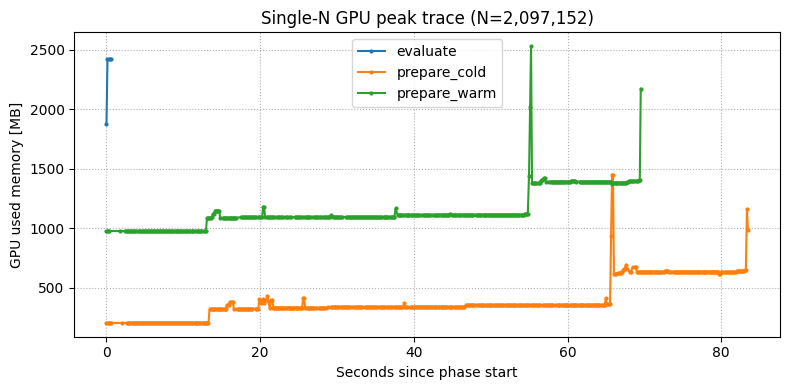

In [12]:
plot_df = peak_trace_df.copy()
plot_df = plot_df[np.isfinite(plot_df["gpu_used_mb"])].reset_index(drop=True)

if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    for phase, sdf in plot_df.groupby("label"):
        t0 = float(sdf["t_s"].min())
        ax.plot(sdf["t_s"] - t0, sdf["gpu_used_mb"], marker="o", markersize=2, label=phase)
    ax.legend()
    ax.set_xlabel("Seconds since phase start")
    ax.set_ylabel("GPU used memory [MB]")
    ax.set_title(f"Single-N GPU peak trace (N={num_particles:,})")
    ax.grid(True, linestyle=":", linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    print("No GPU peak trace available. Is nvidia-smi visible inside the notebook environment?")


In [13]:
component_peak_df = pd.DataFrame()
component_trace_df = pd.DataFrame()
if bool(component_peak_enabled):
    component_peak_parts = []
    component_trace_parts = []
    for component_mode in ["tree", "interactions", "m2l", "l2l", "prepare"]:
        part_df, trace_df = run_component_worker_with_peak(component_mode, runs=1, warmup=0)
        component_peak_parts.append(part_df)
        component_trace_parts.append(trace_df)
    component_peak_df = pd.concat(component_peak_parts, ignore_index=True)
    component_trace_df = pd.concat(component_trace_parts, ignore_index=True)
    component_peak_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_component_peak_summary.csv", index=False)
    component_trace_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_component_peak_trace.csv", index=False)
component_peak_df


""


In [14]:
if component_peak_df.empty:
    print("Component worker breakdown disabled.")
else:
    print("=== Isolated Prepare Component Peaks ===")
    display(component_peak_df)

component_plot_df = component_trace_df.copy()
if "gpu_used_mb" in component_plot_df.columns:
    component_plot_df = component_plot_df[np.isfinite(component_plot_df["gpu_used_mb"])].reset_index(drop=True)
else:
    component_plot_df = pd.DataFrame()

if not component_plot_df.empty:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for component_name, sdf in component_plot_df.groupby("component"):
        t0 = float(sdf["t_s"].min())
        ax.plot(sdf["t_s"] - t0, sdf["gpu_used_mb"], marker="o", markersize=2, label=component_name)
    ax.legend()
    ax.set_xlabel("Seconds since worker start")
    ax.set_ylabel("GPU used memory [MB]")
    ax.set_title(f"Isolated worker peak trace by component (N={num_particles:,})")
    ax.grid(True, linestyle=":", linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    print("No component peak trace available.")


Component worker breakdown disabled.
No component peak trace available.


In [15]:
memory_sweep_df = pd.DataFrame()
memory_sweep_completed = False
memory_sweep_run_id = None
memory_sweep_candidate_df = pd.DataFrame(memory_sweep_traversal_candidates)
if bool(memory_sweep_enabled):
    memory_sweep_run_id = time.strftime("%Y%m%d_%H%M%S")
    print(f"Starting memory sweep run_id={memory_sweep_run_id}")
    print("Active traversal candidates:")
    display(memory_sweep_candidate_df)
    sweep_rows = []
    for traversal_cfg in memory_sweep_traversal_candidates:
        for nearfield_chunk in memory_sweep_nearfield_chunks:
            for m2l_chunk in memory_sweep_m2l_chunks:
                tuned_kwargs = with_memory_knobs(
                    fmm_kwargs,
                    traversal_cfg=traversal_cfg,
                    nearfield_edge_chunk_size=nearfield_chunk,
                    m2l_chunk_size=m2l_chunk,
                )
                part_df, _ = run_component_worker_with_peak(
                    "sweep",
                    runs=1,
                    warmup=1,
                    fmm_kwargs_override=tuned_kwargs,
                )
                row = _annotate_worker_row(
                    part_df,
                    traversal_cfg=traversal_cfg,
                    run_id_field="memory_sweep_run_id",
                    run_id=memory_sweep_run_id,
                    extra_fields={
                        "m2l_chunk_size": int(m2l_chunk),
                        "nearfield_edge_chunk_size": int(nearfield_chunk),
                    },
                )
                sweep_rows.append(row)
    memory_sweep_df = pd.DataFrame(sweep_rows)
    memory_sweep_completed = True
    memory_sweep_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_memory_sweep.csv", index=False)
memory_sweep_df


""


In [16]:
if not bool(memory_sweep_enabled):
    print("Memory sweep disabled.")
elif not bool(memory_sweep_completed):
    print("Memory sweep did not complete in this kernel state. Re-run the sweep cell.")
elif memory_sweep_df.empty:
    print("Memory sweep completed but produced no rows.")
else:
    print(f"Sweep run_id={memory_sweep_run_id}")
    print("Active traversal candidates used for this sweep:")
    display(memory_sweep_candidate_df)
    stable_df = memory_sweep_df[memory_sweep_df["fit_status"] == "ok"].copy()
    if bool(prepare_analysis_enabled) and not stable_df.empty:
        print("=== Best Warm Prepare Configurations ===")
        prepare_df = stable_df.sort_values(["gpu_peak_delta_mb", "prepare_mean_seconds", "evaluate_mean_seconds"], ascending=[True, True, True])
        display(prepare_df[["gpu_peak_delta_mb", "prepare_mean_seconds", "evaluate_mean_seconds", "m2l_chunk_size", "nearfield_edge_chunk_size", "max_pair_queue", "process_block", "max_interactions_per_node", "max_neighbors_per_leaf"]].head(12))
        print("\n=== Fastest End-to-End Stable Configurations ===")
        end_to_end_df = stable_df.assign(total_phase_seconds=stable_df["prepare_mean_seconds"] + stable_df["evaluate_mean_seconds"])
        end_to_end_df = end_to_end_df.sort_values(["total_phase_seconds", "gpu_peak_delta_mb"], ascending=[True, True])
        display(end_to_end_df[["total_phase_seconds", "prepare_mean_seconds", "evaluate_mean_seconds", "gpu_peak_delta_mb", "m2l_chunk_size", "nearfield_edge_chunk_size", "max_pair_queue", "process_block", "max_interactions_per_node", "max_neighbors_per_leaf"]].head(12))
        print("\n=== Lowest-Peak Stable Configurations ===")
    else:
        print("=== Lowest-Peak Stable Configurations ===")
    if stable_df.empty:
        print("No stable configuration found.")
    else:
        stable_df = stable_df.sort_values(["gpu_peak_delta_mb", "wall_seconds"], ascending=[True, True])
        display(stable_df[["gpu_peak_delta_mb", "wall_seconds", "m2l_chunk_size", "nearfield_edge_chunk_size", "max_pair_queue", "process_block", "max_interactions_per_node", "max_neighbors_per_leaf"]].head(12))

    print("\n=== Capacity / OOM Failures ===")
    fail_df = memory_sweep_df[memory_sweep_df["fit_status"] != "ok"].copy()
    if fail_df.empty:
        print("No failures.")
    else:
        display(fail_df[["fit_status", "gpu_peak_delta_mb", "m2l_chunk_size", "nearfield_edge_chunk_size", "max_pair_queue", "process_block", "max_interactions_per_node", "max_neighbors_per_leaf", "error"]])


Memory sweep disabled.


In [17]:
positions, masses, _ = bench_utils.generate_random_distribution(
    int(num_particles),
    key=jax.random.PRNGKey(seed),
    dtype=working_dtype,
)

In [18]:
prepare_peak_compare_df = pd.DataFrame()
prepare_peak_compare_completed = False
prepare_peak_compare_run_id = None
prepare_peak_compare_candidate_df = pd.DataFrame([
    {
        "label": str(candidate["label"]),
        **_traversal_row_fields(candidate.get("traversal_cfg")),
        "m2l_chunk_size": int(candidate["m2l_chunk_size"]),
        "nearfield_edge_chunk_size": int(candidate["nearfield_edge_chunk_size"]),
    }
    for candidate in prepare_peak_compare_candidates
])
if bool(prepare_peak_compare_enabled):
    prepare_peak_compare_run_id = time.strftime("%Y%m%d_%H%M%S")
    print(f"Starting prepare-peak comparison run_id={prepare_peak_compare_run_id}")
    print("Active prepare-peak candidates:")
    display(prepare_peak_compare_candidate_df)
    compare_rows = []
    for candidate in prepare_peak_compare_candidates:
        tuned_kwargs = with_memory_knobs(
            fmm_kwargs,
            traversal_cfg=candidate.get("traversal_cfg"),
            nearfield_edge_chunk_size=candidate.get("nearfield_edge_chunk_size"),
            m2l_chunk_size=candidate.get("m2l_chunk_size"),
        )
        row, _, _, _, _ = run_prepare_peak_compare(
            tuned_kwargs,
            label=str(candidate["label"]),
            warmup=1,
        )
        row.update(_traversal_row_fields(candidate.get("traversal_cfg")))
        row["m2l_chunk_size"] = int(candidate["m2l_chunk_size"])
        row["nearfield_edge_chunk_size"] = int(candidate["nearfield_edge_chunk_size"])
        row["prepare_peak_compare_run_id"] = str(prepare_peak_compare_run_id)
        compare_rows.append(row)
    prepare_peak_compare_df = pd.DataFrame(compare_rows)
    prepare_peak_compare_completed = True
    prepare_peak_compare_df.to_csv(
        single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_prepare_peak_compare.csv",
        index=False,
    )

if not bool(prepare_peak_compare_enabled):
    print("Prepare-peak comparison disabled.")
elif not bool(prepare_peak_compare_completed):
    print("Prepare-peak comparison did not complete in this kernel state. Re-run the prepare-peak comparison cell.")
elif prepare_peak_compare_df.empty:
    print("Prepare-peak comparison completed but produced no rows.")
else:
    print(f"Prepare-peak comparison run_id={prepare_peak_compare_run_id}")
    print("Active prepare-peak candidates used for this run:")
    display(prepare_peak_compare_candidate_df)
    display(
        prepare_peak_compare_df[[
            "label",
            "gpu_peak_delta_mb",
            "gpu_peak_used_mb",
            "wall_seconds",
            "prepared_state_mb",
            "m2l_chunk_size",
            "nearfield_edge_chunk_size",
            "max_pair_queue",
            "process_block",
            "max_interactions_per_node",
            "max_neighbors_per_leaf",
        ]].sort_values(["gpu_peak_delta_mb", "wall_seconds"], ascending=[True, True])
    )


Prepare-peak comparison disabled.


In [19]:
mac_compare_df = pd.DataFrame()
mac_compare_completed = False
mac_compare_run_id = None
mac_compare_candidate_df = pd.DataFrame({"mac_type": list(mac_compare_types)})
if bool(mac_compare_enabled):
    mac_compare_run_id = time.strftime("%Y%m%d_%H%M%S")
    print(f"Starting MAC comparison run_id={mac_compare_run_id}")
    print("Active MAC candidates:")
    display(mac_compare_candidate_df)
    mac_rows = []
    baseline_traversal_cfg, baseline_nearfield_chunk, baseline_m2l_chunk = _baseline_memory_knobs()
    for mac_type in mac_compare_types:
        tuned_kwargs = with_memory_knobs(
            fmm_kwargs,
            traversal_cfg=baseline_traversal_cfg,
            nearfield_edge_chunk_size=baseline_nearfield_chunk,
            m2l_chunk_size=baseline_m2l_chunk,
            mac_type=mac_type,
        )
        part_df, _ = run_component_worker_with_peak(
            "sweep",
            runs=1,
            warmup=int(mac_compare_warmup),
            fmm_kwargs_override=tuned_kwargs,
        )
        row = _annotate_worker_row(
            part_df,
            traversal_cfg=baseline_traversal_cfg,
            run_id_field="mac_compare_run_id",
            run_id=mac_compare_run_id,
            extra_fields={
                "mac_type": str(mac_type),
                "m2l_chunk_size": int(baseline_m2l_chunk),
                "nearfield_edge_chunk_size": int(baseline_nearfield_chunk),
            },
        )
        mac_rows.append(row)
    mac_compare_df = pd.DataFrame(mac_rows)
    mac_compare_completed = True
    mac_compare_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_mac_compare.csv", index=False)

if not bool(mac_compare_enabled):
    print("MAC comparison disabled.")
elif not bool(mac_compare_completed):
    print("MAC comparison did not complete in this kernel state. Re-run the MAC comparison cell.")
elif mac_compare_df.empty:
    print("MAC comparison completed but produced no rows.")
else:
    print(f"MAC comparison run_id={mac_compare_run_id}")
    display(mac_compare_df[["mac_type", "fit_status", "gpu_peak_delta_mb", "wall_seconds", "m2l_chunk_size", "nearfield_edge_chunk_size", "max_pair_queue", "process_block", "max_interactions_per_node", "max_neighbors_per_leaf", "error"]].sort_values(["fit_status", "gpu_peak_delta_mb", "wall_seconds"], ascending=[True, True, True]))


MAC comparison disabled.


In [20]:
leaf_size_production_compare_df = pd.DataFrame()
leaf_size_production_compare_completed = False
leaf_size_production_compare_run_id = None

leaf_size_production_compare_candidate_df = pd.DataFrame(
    {
        "leaf_size": [int(v) for v in leaf_size_production_compare_leaf_sizes],
    }
)

if bool(leaf_size_production_compare_enabled):
    leaf_size_production_compare_run_id = time.strftime("%Y%m%d_%H%M%S")
    print(f"Starting leaf-size production comparison run_id={leaf_size_production_compare_run_id}")
    print("Leaf-size candidates:")
    display(leaf_size_production_compare_candidate_df)

    compare_rows = []
    baseline_traversal_cfg, baseline_nearfield_chunk, baseline_m2l_chunk = _baseline_memory_knobs()

    original_leaf_size = int(leaf_size)
    try:
        for leaf in [int(v) for v in leaf_size_production_compare_leaf_sizes]:
            globals()["leaf_size"] = int(leaf)
            tuned_kwargs = with_memory_knobs(
                fmm_kwargs,
                traversal_cfg=baseline_traversal_cfg,
                nearfield_edge_chunk_size=baseline_nearfield_chunk,
                m2l_chunk_size=baseline_m2l_chunk,
            )
            part_df, _ = run_component_worker_with_peak(
                "sweep",
                runs=int(leaf_size_production_compare_runs),
                warmup=int(leaf_size_production_compare_warmup),
                fmm_kwargs_override=tuned_kwargs,
            )
            row = _annotate_worker_row(
                part_df,
                traversal_cfg=baseline_traversal_cfg,
                run_id_field="leaf_size_production_compare_run_id",
                run_id=leaf_size_production_compare_run_id,
                extra_fields={
                    "leaf_size": int(leaf),
                    "m2l_chunk_size": int(baseline_m2l_chunk),
                    "nearfield_edge_chunk_size": int(baseline_nearfield_chunk),
                    "lane_label": str(single_n_lane_label),
                    "target_block_size": int(single_n_target_block_size),
                },
            )
            row["prepare_plus_evaluate_seconds"] = float(row.get("prepare_mean_seconds", np.nan)) + float(row.get("evaluate_mean_seconds", np.nan))
            compare_rows.append(row)
    finally:
        globals()["leaf_size"] = int(original_leaf_size)

    leaf_size_production_compare_df = pd.DataFrame(compare_rows)
    leaf_size_production_compare_completed = True
    leaf_size_production_compare_df.to_csv(
        single_n_output_dir / f"single_n_{num_particles}_{single_n_run_suffix}_leaf_size_production_compare.csv",
        index=False,
    )

leaf_size_production_compare_df


Starting leaf-size production comparison run_id=20260421_214405
Leaf-size candidates:


,leaf_size
0,128
1,256


,component,gpu_used_before_mb,gpu_used_after_mb,gpu_peak_used_mb,gpu_peak_delta_mb,wall_seconds,error,error_type,num_particles,mean_seconds,...,max_interactions_per_node,max_neighbors_per_leaf,leaf_size,m2l_chunk_size,nearfield_edge_chunk_size,lane_label,target_block_size,leaf_size_production_compare_run_id,fit_status,prepare_plus_evaluate_seconds
0,sweep,394.0,0.0,5794.0,5400.0,0.582062,,,2097152,0.582062,...,32768,16384,128,1024,64,fast_lane,8,20260421_214405,ok,5.116676
1,sweep,414.0,0.0,1654.0,1240.0,0.693441,,,2097152,0.693441,...,32768,16384,256,1024,64,fast_lane,8,20260421_214405,ok,2.913547


In [21]:
if not bool(leaf_size_production_compare_enabled):
    print("Leaf-size production comparison disabled.")
elif not bool(leaf_size_production_compare_completed):
    print("Leaf-size production comparison did not complete in this kernel state. Re-run the comparison cell.")
elif leaf_size_production_compare_df.empty:
    print("Leaf-size production comparison completed but produced no rows.")
else:
    print(f"Leaf-size production comparison run_id={leaf_size_production_compare_run_id}")

    display_cols = [
        "leaf_size",
        "fit_status",
        "prepare_mean_seconds",
        "evaluate_mean_seconds",
        "prepare_plus_evaluate_seconds",
        "gpu_peak_delta_mb",
        "gpu_peak_used_mb",
        "mean_seconds",
        "std_seconds",
        "m2l_chunk_size",
        "nearfield_edge_chunk_size",
        "max_pair_queue",
        "process_block",
        "max_interactions_per_node",
        "max_neighbors_per_leaf",
        "error",
    ]
    display_cols = [c for c in display_cols if c in leaf_size_production_compare_df.columns]

    ranked = leaf_size_production_compare_df.sort_values(
        ["fit_status", "evaluate_mean_seconds", "gpu_peak_delta_mb"],
        ascending=[True, True, True],
    )
    display(ranked[display_cols])

    ok_df = leaf_size_production_compare_df[leaf_size_production_compare_df["fit_status"] == "ok"].copy()
    if ok_df.empty:
        print("No successful leaf-size runs to compare.")
    else:
        runtime_winner = ok_df.sort_values(["evaluate_mean_seconds", "gpu_peak_delta_mb"], ascending=[True, True]).iloc[0]
        memory_winner = ok_df.sort_values(["gpu_peak_delta_mb", "evaluate_mean_seconds"], ascending=[True, True]).iloc[0]
        total_winner = ok_df.sort_values(["prepare_plus_evaluate_seconds", "gpu_peak_delta_mb"], ascending=[True, True]).iloc[0]

        recommendation_rows = [
            {
                "criterion": "Fastest evaluate",
                "leaf_size": int(runtime_winner["leaf_size"]),
                "evaluate_mean_seconds": float(runtime_winner.get("evaluate_mean_seconds", np.nan)),
                "gpu_peak_delta_mb": float(runtime_winner.get("gpu_peak_delta_mb", np.nan)),
            },
            {
                "criterion": "Lowest peak memory",
                "leaf_size": int(memory_winner["leaf_size"]),
                "evaluate_mean_seconds": float(memory_winner.get("evaluate_mean_seconds", np.nan)),
                "gpu_peak_delta_mb": float(memory_winner.get("gpu_peak_delta_mb", np.nan)),
            },
            {
                "criterion": "Fastest prepare+evaluate",
                "leaf_size": int(total_winner["leaf_size"]),
                "evaluate_mean_seconds": float(total_winner.get("evaluate_mean_seconds", np.nan)),
                "gpu_peak_delta_mb": float(total_winner.get("gpu_peak_delta_mb", np.nan)),
            },
        ]
        recommendation_df = pd.DataFrame(recommendation_rows)
        print("=== Production Decision A/B ===")
        display(recommendation_df)


Leaf-size production comparison run_id=20260421_214405


,leaf_size,fit_status,prepare_mean_seconds,evaluate_mean_seconds,prepare_plus_evaluate_seconds,gpu_peak_delta_mb,gpu_peak_used_mb,mean_seconds,std_seconds,m2l_chunk_size,nearfield_edge_chunk_size,max_pair_queue,process_block,max_interactions_per_node,max_neighbors_per_leaf,error
0,128,ok,4.534613,0.582062,5.116676,5400.0,5794.0,0.582062,0.0,1024,64,1048576,256,32768,16384,
1,256,ok,2.220106,0.693441,2.913547,1240.0,1654.0,0.693441,0.0,1024,64,1048576,256,32768,16384,


=== Production Decision A/B ===


,criterion,leaf_size,evaluate_mean_seconds,gpu_peak_delta_mb
0,Fastest evaluate,128,0.582062,5400.0
1,Lowest peak memory,256,0.693441,1240.0
2,Fastest prepare+evaluate,256,0.693441,1240.0
